In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler,LabelEncoder,MinMaxScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
from sklearn.linear_model import Perceptron
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

In [45]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Combine train and test
X = np.concatenate([X_train, X_test], axis=0)
y = np.concatenate([y_train, y_test], axis=0)

# Flatten 28x28 -> 784
X = X.reshape(X.shape[0], 784)

# Create pixel column names
pixel_columns = [f"pixel{i}" for i in range(1, 785)]

# Create DataFrame
df = pd.DataFrame(X, columns=pixel_columns)

# Add label column
df.insert(0, "label", y)
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
df['label'].value_counts()

label
1    7877
7    7293
3    7141
2    6990
9    6958
0    6903
6    6876
8    6825
4    6824
5    6313
Name: count, dtype: int64

In [12]:
df.duplicated().value_counts()

False    70000
Name: count, dtype: int64

In [13]:
#preprocessing
x=df.drop('label',axis=1)
y=df['label']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42,stratify=y)

In [15]:
# X_train=X_train.astype('float')/255
# X_test=X_test.astype('float')/255
mm=MinMaxScaler()
X_train=mm.fit_transform(X_train)
X_test=mm.transform(X_test)

In [16]:
#reshape
X_train_img=X_train.reshape(-1,28,28)
X_test_img=X_test.reshape(-1,28,28)

In [17]:
y_train_cat=to_categorical(y_train)
y_test_cat=to_categorical(y_test)

In [18]:
#create Perceptron
Perceptron_model=Sequential(
    [
        Flatten(input_shape=(28,28)),
        Dense(10,activation='softmax')
    ]
)

C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
Perceptron_model.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

In [21]:
history_per=Perceptron_model.fit(
    X_train_img,
    y_train_cat,
    validation_data=(X_test_img,y_test_cat),
    epochs=5,
    batch_size=30,
    verbose=1
    
)

Epoch 1/5
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9121 - loss: 0.3175 - val_accuracy: 0.9080 - val_loss: 0.3234
Epoch 2/5
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9134 - loss: 0.3134 - val_accuracy: 0.9091 - val_loss: 0.3203
Epoch 3/5
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9140 - loss: 0.3097 - val_accuracy: 0.9094 - val_loss: 0.3171
Epoch 4/5
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9147 - loss: 0.3066 - val_accuracy: 0.9102 - val_loss: 0.3153
Epoch 5/5
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9154 - loss: 0.3037 - val_accuracy: 0.9108 - val_loss: 0.3128


In [ ]:
loss,acc=Perceptron_model.evaluate(X_test_img,y_test_cat)
acc

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9250 - loss: 0.8313


0.925000011920929

In [22]:
#create using ANN
ANN_model=Sequential(
    [
        Flatten(input_shape=(28,28)),
        Dense(120,activation='relu'),
        Dense(60,activation='relu'),
        # Dropout(0.5),
        Dense(10,activation='softmax')
    ]
)

In [23]:
ANN_model.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

In [24]:
history_ann=ANN_model.fit(
    X_train_img,y_train_cat,
    validation_data=(X_test_img,y_test_cat),
    verbose=1,
    epochs=5,
    batch_size=30
)

Epoch 1/5
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8323 - loss: 0.6427 - val_accuracy: 0.9048 - val_loss: 0.3318
Epoch 2/5
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9167 - loss: 0.2919 - val_accuracy: 0.9221 - val_loss: 0.2662
Epoch 3/5
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9315 - loss: 0.2398 - val_accuracy: 0.9323 - val_loss: 0.2279
Epoch 4/5
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9417 - loss: 0.2042 - val_accuracy: 0.9391 - val_loss: 0.2043
Epoch 5/5
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9483 - loss: 0.1786 - val_accuracy: 0.9465 - val_loss: 0.1821


In [25]:
loss_ann,ann_acc=ANN_model.evaluate(X_test_img,y_test_cat)
ann_acc

438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9465 - loss: 0.1821


0.9465000033378601

In [26]:
X_train_cnn=X_train_img.reshape(-1,28,28,1)
X_test_cnn=X_test_img.reshape(-1,28,28,1)

In [27]:
#suing CNN
model_cnn=Sequential([
    Conv2D(32,kernel_size=(3,3),input_shape=(28,28,1),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
history_cnn=model_cnn.fit(
    X_train_cnn,y_train_cat,
    validation_data=(X_test_cnn,y_test_cat),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.9649 - loss: 0.1157 - val_accuracy: 0.9827 - val_loss: 0.0559
Epoch 2/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - accuracy: 0.9788 - loss: 0.0714 - val_accuracy: 0.9864 - val_loss: 0.0423
Epoch 3/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.9828 - loss: 0.0570 - val_accuracy: 0.9886 - val_loss: 0.0374
Epoch 4/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.9864 - loss: 0.0453 - val_accuracy: 0.9889 - val_loss: 0.0370
Epoch 5/5
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9891 - loss: 0.0365 - val_accuracy: 0.9904 - val_loss: 0.0357


In [32]:
loss_cnn,acc_cnn=model_cnn.evaluate(X_test_cnn,y_test_cat)
acc_cnn

438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9904 - loss: 0.0357


0.9903571605682373

In [34]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

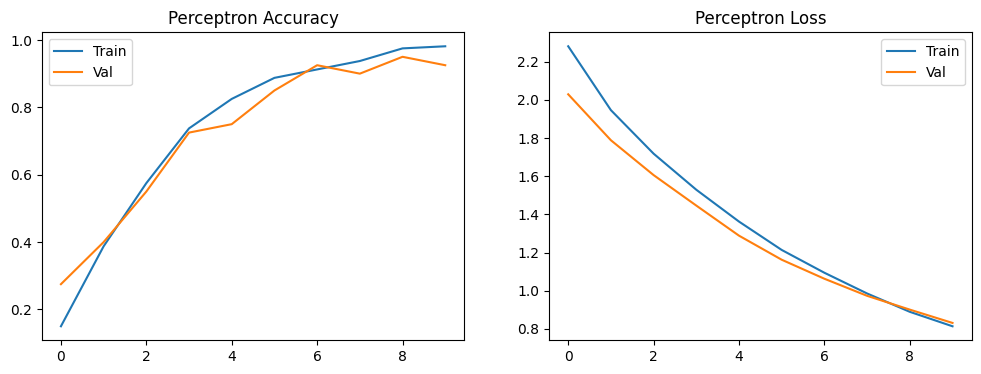

In [ ]:
plot_training(history_per,"Perceptron")

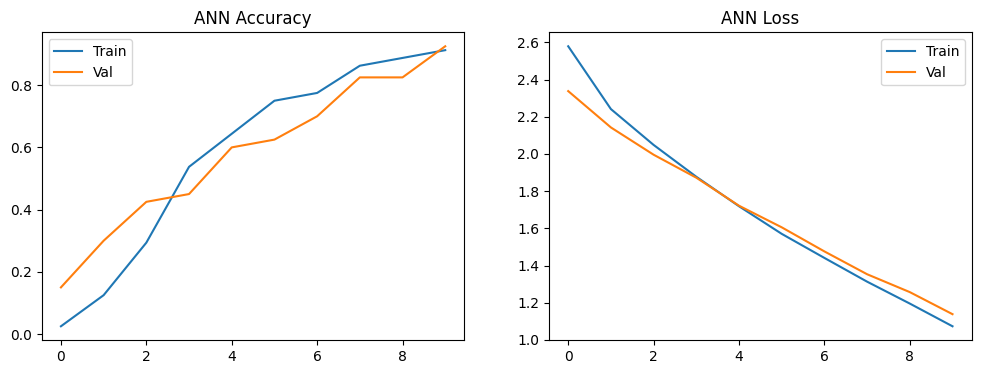

In [ ]:
plot_training(history_ann,"ANN")

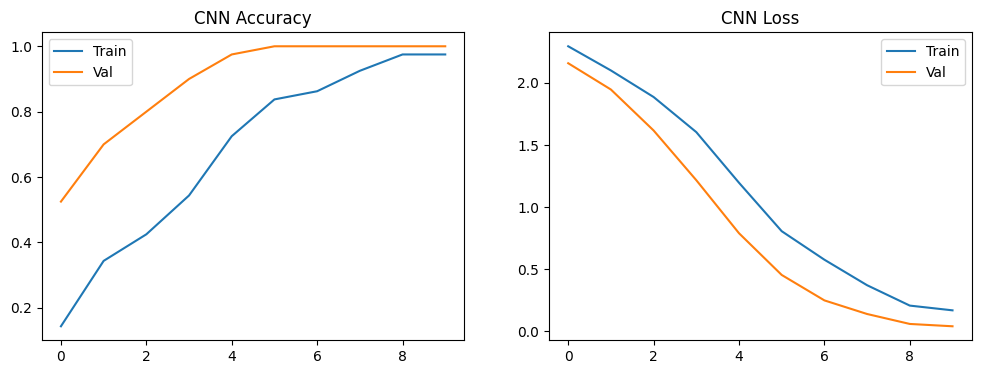

In [ ]:
plot_training(history_cnn,"CNN")

In [36]:
def show_random_predictions(model, X_test, y_test, n=5):
    
    # Randomly choose n images
    indices = np.random.choice(len(X_test), n, replace=False)

    plt.figure(figsize=(12, 3))

    for i, index in enumerate(indices):
        
        # Get image
        image = X_test[index]
        
        # Predict
        prediction = model.predict(
            np.expand_dims(image, axis=0),
            verbose=0
        )
        
        predicted_label = np.argmax(prediction)
        actual_label = np.argmax(y_test[index])

        # Check correct/incorrect
        result = "Correct" if predicted_label == actual_label else "Wrong"

        # Show image
        plt.subplot(1, n, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.axis('off')
        
        plt.title(
            f"Pred: {predicted_label}\n"
            f"Actual: {actual_label}\n"
            f"{result}"
        )

    plt.tight_layout()
    plt.show()

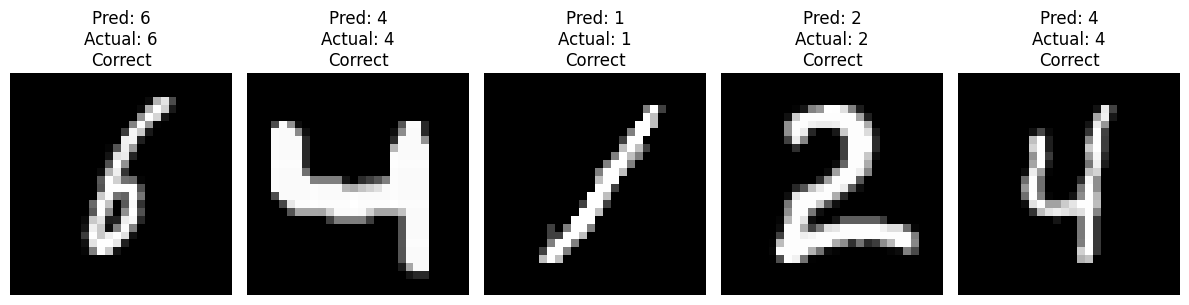

In [39]:
show_random_predictions(
    model_cnn,
    X_test_cnn,
    y_test_cat,
    n=5
)

In [42]:
import joblib
model_cnn.save("cnn_model.keras")
joblib.dump(mm, "mnist_scaler.pkl")

['mnist_scaler.pkl']

In [41]:
df.shape

(70000, 785)

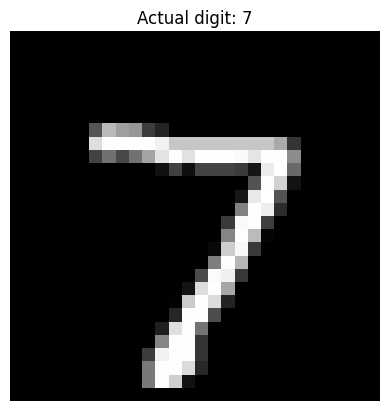

In [49]:
import matplotlib.pyplot as plt

plt.imshow(X_test[0], cmap="gray")
plt.title(f"Actual digit: {y_test[0]}")
plt.axis("off")
plt.show()

In [48]:
# Take the same MNIST image
image = X_test[0]

# Convert 28x28 image into 784 pixels
image_flat = image.reshape(1, 784)

# Apply the SAME scaler used during training
image_scaled = mm.transform(image_flat)

# Reshape for CNN
image_cnn = image_scaled.reshape(1, 28, 28, 1)

# Predict
prediction = model_cnn.predict(
    image_cnn,
    verbose=0
)

# Get predicted digit
predicted_digit = np.argmax(prediction[0])

# Get confidence
confidence = prediction[0][predicted_digit] * 100

print("Actual digit    :", y_test[0])
print("Predicted digit :", predicted_digit)
print("Confidence      :", round(confidence, 2), "%")

Actual digit    : 7
Predicted digit : 7
Confidence      : 100.0 %


C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
